# Teen Social Media & Physical Activity Analysis

**Dataset:** Social Media Impact on Teen Mental Health (Structured, precleaned and standardized from Kaggle)
**Data type:** Unknown. These data are pulled from Kaggle, and I am assuming they are Synthetic  
**Goal:** Explore whether sleep duration predicts exercise frequency, and whether pre-bed phone usage moderates that relationship. 
# This project will serve as an introduction to the data analysis pipeline using python and SQL

In [110]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ChrisDave00\.cache\kagglehub\datasets\algozee\teenager-menthal-healy\versions\1


In [111]:
import pandas as pd
import sqlite3
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visualization
import statsmodels.api as sm
import statsmodels.formula.api as smf # this is to run a lm like R
import numpy as np
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [112]:
# I added the r in front of the file destination to circumvent Python's special use cases for \
# It turns the quote text into raw text to prevent python from interpreting any special characters

mental_health = pd.read_csv(r'C:\Users\ChrisDave00\Box\Self\Job Search\Project One\data\Teen_Mental_Health_Dataset.csv')
print(mental_health.head())

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   

In [113]:
# Writing to a SQLite DB 

conn = sqlite3.connect('mental_health.db') 

mental_health.to_sql("teen_health", conn, if_exists= 'replace', index= False)

1200

In [114]:
# Reading from a SQLite DB
# This is defining the variable that I am using to import the data from 

sleep_phone_on_pa = pd.read_sql("SELECT sleep_hours, age, gender, screen_time_before_sleep, physical_activity FROM teen_health", conn)

sleep_phone_on_pa['gender'] = sleep_phone_on_pa['gender'].map({'male': 1, 'female': 0}) # recoding gender for later analyses


       sleep_hours          age       gender  screen_time_before_sleep  \
count  1200.000000  1200.000000  1200.000000               1200.000000   
mean      6.449417    15.928333     0.512500                  1.740333   
std       1.442677     2.021947     0.500052                  0.716660   
min       4.000000    13.000000     0.000000                  0.500000   
25%       5.200000    14.000000     0.000000                  1.100000   
50%       6.500000    16.000000     1.000000                  1.800000   
75%       7.600000    18.000000     1.000000                  2.400000   
max       9.000000    19.000000     1.000000                  3.000000   

       physical_activity  
count        1200.000000  
mean            1.014500  
std             0.582185  
min             0.000000  
25%             0.500000  
50%             1.000000  
75%             1.500000  
max             2.000000  


Text(0.5, 1.0, 'Total Sleep in Hrs')

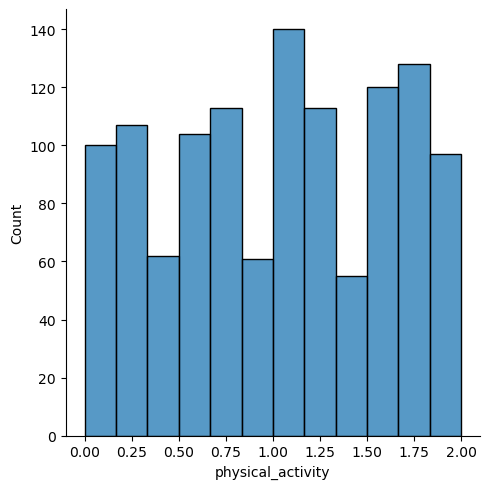

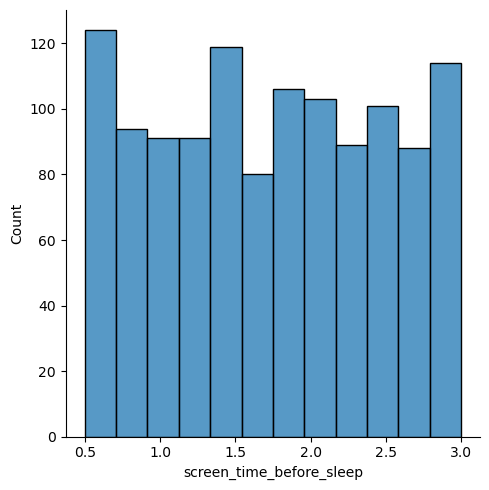

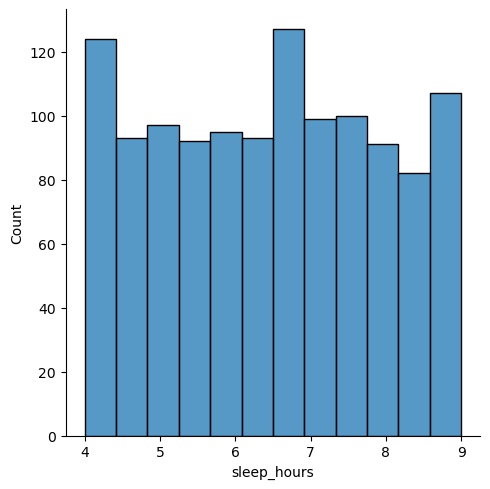

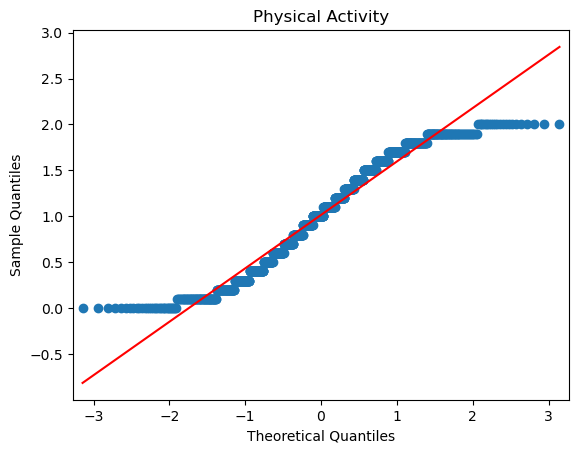

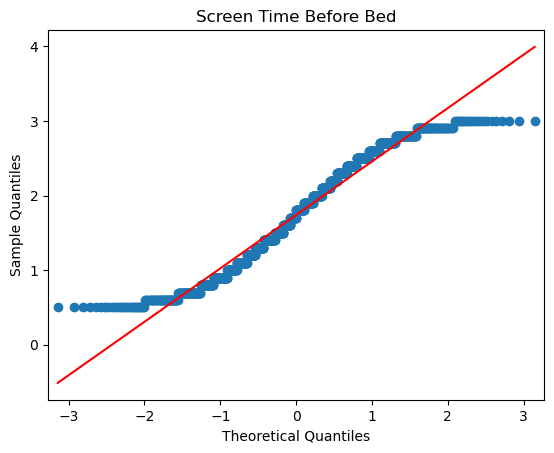

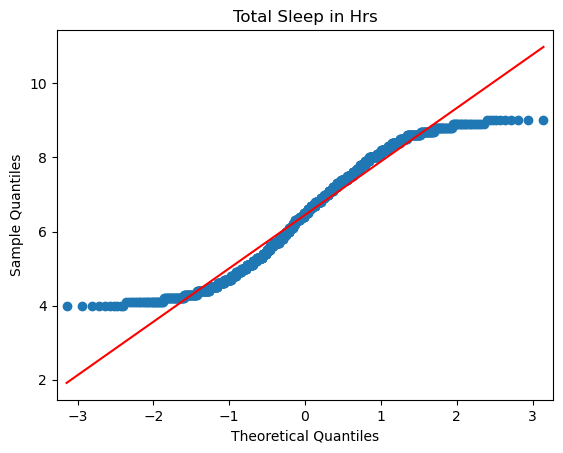

In [115]:
# Before running any analyses, I am going to check that the data loaded properly, and I am going to assess statistical assumptions for  the linear model 

#Verifying the data imported correctly
# print(sleep_phone_on_pa.head())
# sleep_phone_on_pa.info()

#Collecting basic descriptives and checking outliers#
print(sleep_phone_on_pa.describe())

# Check 1 - the normality assumption 

#Histogram
sns.displot(sleep_phone_on_pa["physical_activity"])
sns.displot(sleep_phone_on_pa["screen_time_before_sleep"])
sns.displot(sleep_phone_on_pa["sleep_hours"])

# Q-Q Plot
sm.qqplot(sleep_phone_on_pa["physical_activity"], line ='s')
plt.title('Physical Activity')

sm.qqplot(sleep_phone_on_pa["screen_time_before_sleep"], line ='s')
plt.title('Screen Time Before Bed')

sm.qqplot(sleep_phone_on_pa["sleep_hours"], line ='s')
plt.title('Total Sleep in Hrs')




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sleep_hours               1200 non-null   float64
 1   age                       1200 non-null   int64  
 2   gender                    1200 non-null   int64  
 3   screen_time_before_sleep  1200 non-null   float64
 4   physical_activity         1200 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 47.0 KB


Text(0.5, 1.0, 'Physical Activity')

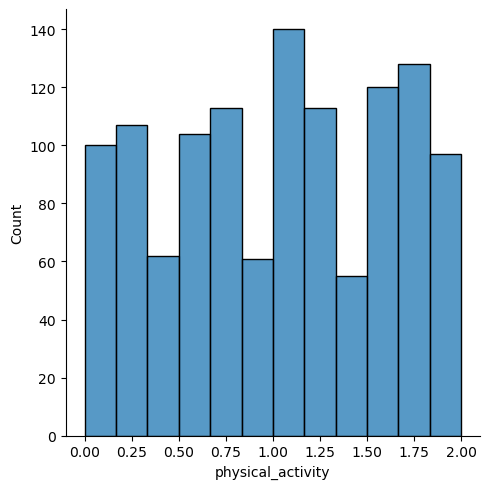

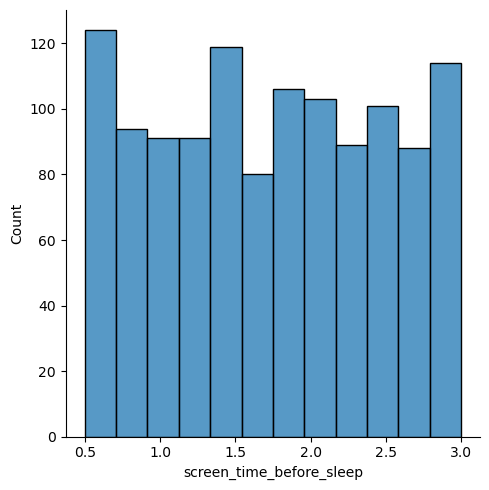

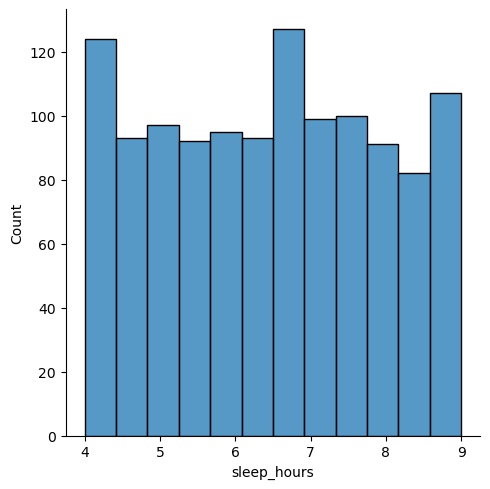

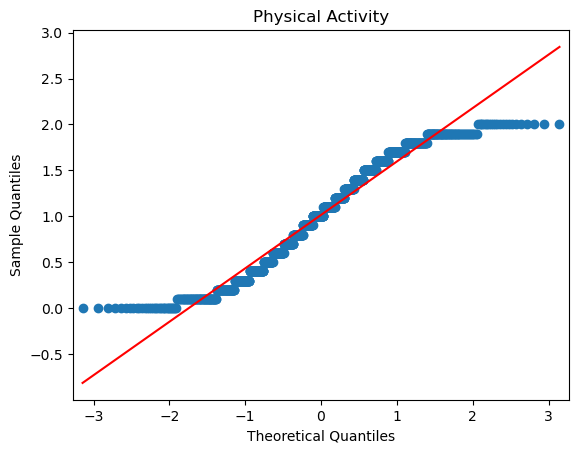

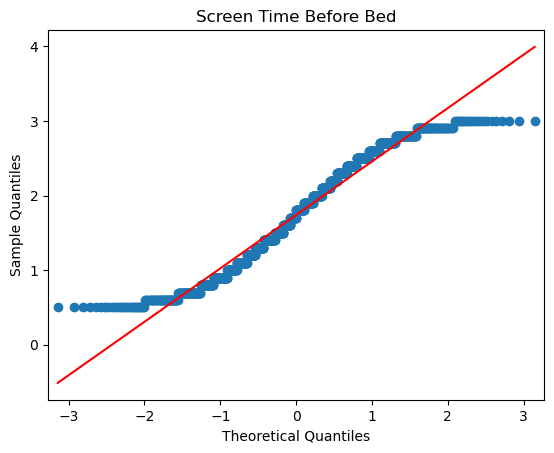

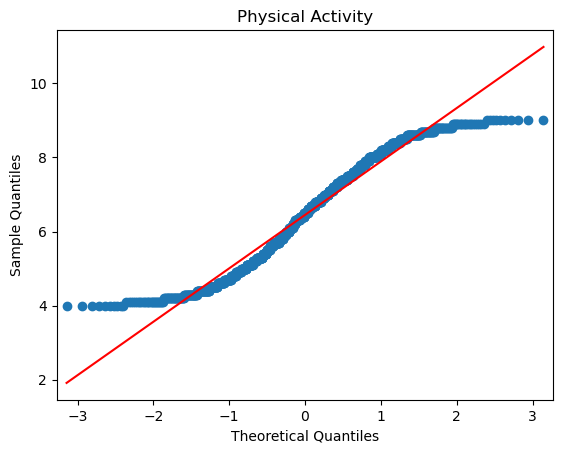

In [116]:
# Before running any analyses, I am going to check that the data loaded properly, and I am going to assess statistical assumptions for  the linear model 

#Verifying the data imported correctly
sleep_phone_on_pa.head()
sleep_phone_on_pa.info()

#Collecting basic descriptives and checking outliers#
sleep_phone_on_pa.describe()

# Check 1 - the normality assumption 

#Histogram
sns.displot(sleep_phone_on_pa["physical_activity"])
sns.displot(sleep_phone_on_pa["screen_time_before_sleep"])
sns.displot(sleep_phone_on_pa["sleep_hours"])

# Q-Q Plot
sm.qqplot(sleep_phone_on_pa["physical_activity"], line ='s')
plt.title('Physical Activity')

sm.qqplot(sleep_phone_on_pa["screen_time_before_sleep"], line ='s')
plt.title('Screen Time Before Bed')

sm.qqplot(sleep_phone_on_pa["sleep_hours"], line ='s')
plt.title('Physical Activity')




*Assessing Normality*

The Normality assumption was assessed for the variables of interest --physical activity, screen time before bed, and total sleep time-- through data visualization using Q-Q plots. All data appear to be normally distributed. 


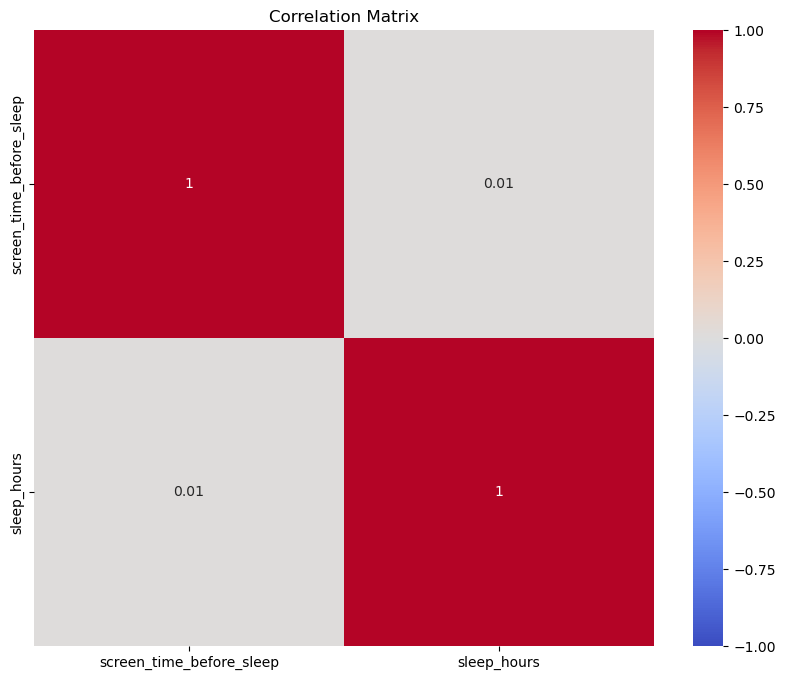

                    Feature        VIF  Tolerance
0                     const  26.683894   0.037476
1  screen_time_before_sleep   1.000105   0.999895
2               sleep_hours   1.000105   0.999895


In [117]:
# Assessing Multicollinearity 


#Correlation Matrix
correl_data= sleep_phone_on_pa[['screen_time_before_sleep', 'sleep_hours']]

corr_matrix = correl_data.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


# Variance inflation Factor
X = sleep_phone_on_pa[['screen_time_before_sleep', 'sleep_hours']]

# Adding a constant so VIF function will work
X = add_constant(X)

# Calculating VIF for each predictor. Adding tolerance as well because it makes more sense to me
health_multico = pd.DataFrame()
health_multico['Feature'] = X.columns # Uses the column names from X as row values in the Feature column
health_multico['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] #This iterates through each variables in df X and computes the VIF. X.shape[1] iterates over each column index until all columns are covered
health_multico["Tolerance"] = 1 / health_multico['VIF']
print(health_multico)


*Testing Assumption: Multicollinearity*

Multicollinearity assumption was tested using three methods: zero-order correlations, variance inflation factor, and tolerance

From the output of these correlation matrix, the variables of interest are almost are practically uncorrelated
From the output of the VIF analysis, the variables of interest appeared to be entirely uncorrelated
From the output of the tolerance analysis, the variables of interest are not correlated. Note: Although including VIF and tolerance is redundant, I am more familiar with interpreting tolerance, so I figured learning how to do both would be worthwhile

Note: Calculating VIF requires running a regression for each predictor, which is how the necessary R² values are obtained. For OLS regression to work properly, a constant must be defined. This is done using the **add_constant** function. Once the constant is added, the variance_inflation_factor function can run the necessary regressions and calculate the VIF for each predictor. This is new to me as the lm() function in R does automatically adds a constant.

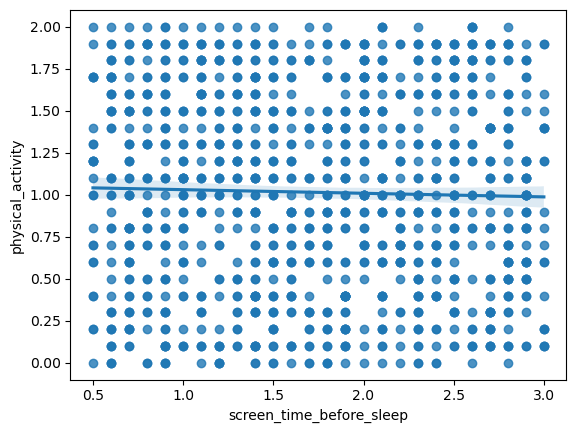

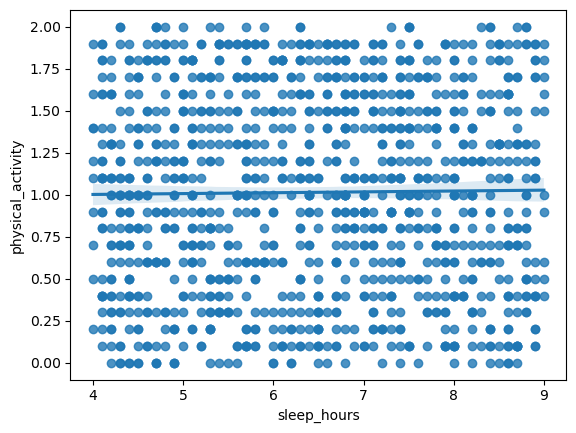

In [118]:
# Checking Linearity 

sns.regplot(x= "screen_time_before_sleep", y = "physical_activity", data = sleep_phone_on_pa)
plt.show()

sns.regplot(x= "sleep_hours", y = "physical_activity", data = sleep_phone_on_pa)
plt.show()


*Assumption Assessment: Linearity*

To assess the linearity assumption, I looked at scatterplots for both predictors. Based on scatterplot interpretation, these data are not linear. This is likely due to the dataset being synthetic.

In [119]:
# Running a multiple regression and the interaciton

#Centering predictors
sleep_phone_on_pa["screen_time_before_sleep_C"] = sleep_phone_on_pa["screen_time_before_sleep"] - sleep_phone_on_pa["screen_time_before_sleep"].mean()
sleep_phone_on_pa["sleep_hours_C"] = sleep_phone_on_pa["sleep_hours"] - sleep_phone_on_pa["sleep_hours"].mean()

paBySleep_Screen = smf.ols("physical_activity ~ gender + age + sleep_hours_C + screen_time_before_sleep_C", data=sleep_phone_on_pa)

results = paBySleep_Screen.fit()

print(results.summary())



#Moderation analysis

#Statsmodels already adds the main effects
paBySleep_Screen_interact = smf.ols("physical_activity ~ gender + age + sleep_hours_C * screen_time_before_sleep_C", data=sleep_phone_on_pa)

results_interact = paBySleep_Screen_interact.fit()

print(results_interact.summary())

sm.stats.anova_lm(results, results_interact)





                            OLS Regression Results                            
Dep. Variable:      physical_activity   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3944
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.813
Time:                        20:54:06   Log-Likelihood:                -1052.3
No. Observations:                1200   AIC:                             2115.
Df Residuals:                    1195   BIC:                             2140.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1195.0,405.851963,0.0,NaN,NaN,NaN
1,1194.0,405.780635,1.0,0.071328,0.209881,0.646944


0       0.503576
1      -0.198868
2      -1.042114
3      -0.226066
4       0.435109
          ...   
1195   -0.007350
1196   -0.629170
1197   -0.232522
1198   -0.423761
1199   -0.121386
Length: 1200, dtype: float64


Text(0, 0.5, 'residuals')

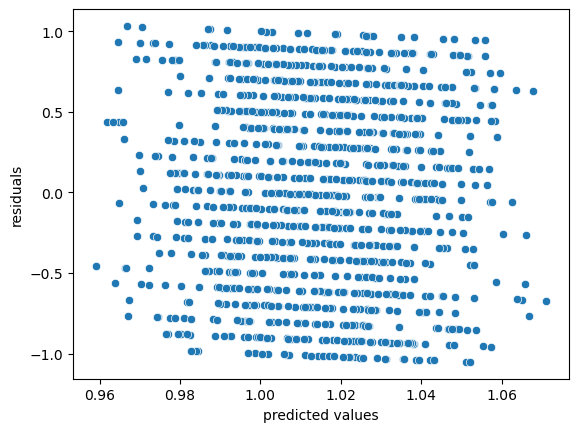

In [120]:
#Testing for Heteroscedasticity 

print(results.resid)

het_X = results.fittedvalues
het_Y = results.resid

sns.scatterplot(x = het_X, y = het_Y)
plt.xlabel("predicted values")
plt.ylabel("residuals")

*Assumption Assessment: Heteroscesdasticity*

The assumption of homoscedasticity states that the variance of the residual errors will be consistent across all predicted values. Breaking this assumption increases the chances of type I and II error. To assess this, I plotted the predicted values against the residuals. From interpreting this plot, this assumption has not been violated. The residuals appear to be evenly spread across the range of predicted values, suggesting consistency in variance

*Multiple Regression & Moderation Interpretation*

A multiple regression was run to assess the effects of sleep duration and screen time before bed on physical activity levels. The model was insignificant (p = .878), suggesting that neither sleep nor screen time before bed influences physical activity. A priori, a moderation analysis was conducted to determine whether the influence of sleep on physical activity depended on levels of screen time before bed. This analysis was also insignificant (p = .647). Taken together, physical activity levels do not appear to be influenced by sleep duration, screen time before bed, or any combination of the two. These findings should be interpreted with caution given the synthetic nature of the dataset.

## Exporting Results to SQL for Dashboard Visualization

The following code exports key analysis outputs to a SQLite database. SQL views are then created to format and structure the data for display in Power BI. I wrote all of this to practice the full data pipeline primarily through SQL.

In [128]:
#creating df with test statistics to upload to SQL for PowerBI
regression_results = pd.DataFrame()
regression_results["F-statistic"] = [results.fvalue, results_interact.fvalue] 
regression_results["F-pvalue"] = [results.f_pvalue, results_interact.f_pvalue] 
regression_results["R-Squared"] = [results.rsquared, results_interact.rsquared] 
regression_results["df_MS"] = [results.df_model, results_interact.df_model]
regression_results["df_MSE"] = [results.df_resid, results_interact.df_resid]  
regression_results["F-statistic"] = [results.fvalue, results_interact.fvalue] 

regression_results.to_sql("regression_results", conn, if_exists= 'replace', index= False)

regression_results.head()


#This looks only at the table with the coefficient 
results.summary2().tables[1]

model_temp1 = results.summary2().tables[1] 
model_temp1["model_number"] = 1 

model_temp2 = results_interact.summary2().tables[1] 
model_temp2["model_number"] = 2 

regression_coef = pd.concat([model_temp1, model_temp2])
regression_coef.insert(0, 'model_number', regression_coef.pop('model_number'))
print(regression_coef)

regression_coef.to_sql("regression_coef", conn, if_exists= 'replace', index= True)


                                          model_number     Coef.  Std.Err.  \
Intercept                                            1  0.945206  0.134924   
gender                                               1  0.019445  0.033689   
age                                                  1  0.003725  0.008348   
sleep_hours_C                                        1  0.005444  0.011672   
screen_time_before_sleep_C                           1 -0.022030  0.023562   
Intercept                                            2  0.944160  0.134988   
gender                                               2  0.020160  0.033736   
age                                                  2  0.003772  0.008352   
sleep_hours_C                                        2  0.005449  0.011676   
screen_time_before_sleep_C                           2 -0.022370  0.023581   
sleep_hours_C:screen_time_before_sleep_C             2 -0.007521  0.016416   

                                                 t         P>|t

11

In [129]:
# Verifies the regression coefficient table exists in the database before creating views
pd.read_sql("SELECT * FROM regression_coef", conn)

# Drops existing views to allow recreation with updated formatting
conn.execute("DROP VIEW IF EXISTS model1_coef")
conn.execute("DROP VIEW IF EXISTS model2_coef")

# Creates a formatted view for Model 1 (main effects only)
# Renames raw variable names to readable labels
# Combines coefficient and standard error into a single β(SE) column using string concatenation
# Note: SQLite does not have a built-in CONCAT function, so the || operator is used instead
# Adds a Sort_Order column to control display order in Power BI
conn.execute(""" CREATE VIEW IF NOT EXISTS model1_coef AS
    SELECT 
    model_number,
   CASE [index]
        
        WHEN 'age' THEN 'Age'
        WHEN 'gender' THEN 'Gender'
        WHEN 'sleep_hours_C' THEN 'Time Asleep (Hours)'
        WHEN 'screen_time_before_sleep_C' THEN 'Screen Time (Hours)'
        ELSE [index]
    END AS Predictor,
    ROUND("Coef.", 2) || '(' || ROUND("Std.Err.", 2) || ')' AS "\u03B2(SE)",
    ROUND("P>|t|", 2) AS "P Value",
    CASE [index]
    WHEN 'Intercept' THEN 1
    WHEN 'age' THEN 2
    WHEN 'gender' THEN 3
    WHEN 'sleep_hours_C' THEN 4
    WHEN 'screen_time_before_sleep_C' THEN 5
END AS Sort_Order
FROM regression_coef WHERE model_number = 1 
""")

# Creates a formatted view for Model 2 (moderation model with interaction term)
# Adds Sleep x Screen Time as an additional predictor row
conn.execute(""" CREATE VIEW IF NOT EXISTS model2_coef AS
      SELECT 
    model_number,
    CASE [index]
      
        WHEN 'age' THEN 'Age'
        WHEN 'gender' THEN 'Gender'
        WHEN 'sleep_hours_C' THEN 'Time Asleep (Hours)'
        WHEN 'screen_time_before_sleep_C' THEN 'Screen Time (Hours)'
        WHEN 'sleep_hours_C:screen_time_before_sleep_C' THEN 'Sleep x Screen Time'	
        ELSE [index]
    END AS Predictor,
    ROUND("Coef.", 2) || '(' || ROUND("Std.Err.", 2) || ')' AS "\u03B2(SE)",
    ROUND("P>|t|", 2) AS "P Value",
    CASE [index]
        WHEN 'Intercept' THEN 1
        WHEN 'age' THEN 2
        WHEN 'gender' THEN 3
        WHEN 'sleep_hours_C' THEN 4
        WHEN 'screen_time_before_sleep_C' THEN 5
        WHEN 'sleep_hours_C:screen_time_before_sleep_C' THEN 6
    END AS Sort_Order   
FROM regression_coef WHERE model_number = 2  
""")



In [130]:
# pd.read_sql("SELECT * FROM (model1_coef, model2_coef)", conn)
# pd.read_sql("SELECT * FROM model2_coef", conn)
pd.read_sql("SELECT * FROM model1_coef", conn)


,model_number,Predictor,β(SE),P Value,Sort_Order
0,1,Intercept,0.95(0.13),0.00,1
1,1,Gender,0.02(0.03),0.56,3
2,1,Age,0.0(0.01),0.66,2
3,1,Time Asleep (Hours),0.01(0.01),0.64,4
4,1,Screen Time (Hours),-0.02(0.02),0.35,5


In [131]:
# Had issues with db being locked, so this esets the database connection to clear any locks from previous sessions

conn.close()
conn = sqlite3.connect('mental_health.db')

# Creates a descriptives table with mean and SD for each predictor and the outcome variable
descriptives = pd.DataFrame({
    'Predictor': ['Sleep Hours', 'Screen Time Before Sleep', 'Physical Activity', 'Age'],
    'Mean': [
        round(sleep_phone_on_pa['sleep_hours'].mean(), 2),
        round(sleep_phone_on_pa['screen_time_before_sleep'].mean(), 2),
        round(sleep_phone_on_pa['physical_activity'].mean(), 2),
        round(sleep_phone_on_pa['age'].mean(), 2),
    ],
    'SD': [
        round(sleep_phone_on_pa['sleep_hours'].std(), 2),
        round(sleep_phone_on_pa['screen_time_before_sleep'].std(), 2),
        round(sleep_phone_on_pa['physical_activity'].std(), 2),
        round(sleep_phone_on_pa['age'].std(), 2),
    ]
})

# Creates a descriptives table with mean and SD for each predictor and the outcome variable
descriptives.to_sql("descriptive", conn, if_exists='replace', index=False)


# Creates a view that sorts predictors in a meaningful order for display in Power BI
conn.execute("DROP VIEW IF EXISTS descriptives_view")
conn.execute("""CREATE VIEW IF NOT EXISTS descriptives_view AS
    SELECT
        CASE Predictor
            WHEN 'Age' THEN 2
            WHEN 'Sleep Hours' THEN 4
            WHEN 'Screen Time Before Sleep' THEN 3
            WHEN 'Physical Activity' THEN 1
        END AS Sort_Order,
        Predictor,
        Mean,
        SD
    FROM descriptive
    ORDER BY Sort_Order
""")

In [132]:
# Creates a SQL view that bins sleep hours into 1-hour intervals and calculates 
# the average physical activity for each bin. Used for the non-technical dashboard.

conn.execute("DROP VIEW IF EXISTS grouped_sleep_pa")
conn.execute("""CREATE VIEW IF NOT EXISTS grouped_sleep_pa AS
    SELECT 
        CASE 
            WHEN sleep_hours >= 4 AND sleep_hours < 5 THEN '4-5 hrs'
            WHEN sleep_hours >= 5 AND sleep_hours < 6 THEN '5-6 hrs'
            WHEN sleep_hours >= 6 AND sleep_hours < 7 THEN '6-7 hrs'
            WHEN sleep_hours >= 7 AND sleep_hours < 8 THEN '7-8 hrs'
            WHEN sleep_hours >= 8 AND sleep_hours <= 9 THEN '8-9 hrs'
        END AS sleep_bin,
      CASE 
            WHEN sleep_hours >= 4 AND sleep_hours < 5 THEN 1
            WHEN sleep_hours >= 5 AND sleep_hours < 6 THEN 2
            WHEN sleep_hours >= 6 AND sleep_hours < 7 THEN 3
            WHEN sleep_hours >= 7 AND sleep_hours < 8 THEN 4
            WHEN sleep_hours >= 8 AND sleep_hours <= 9 THEN 5
        END AS Sort_Order,
        physical_activity
    FROM teen_health 
    WHERE sleep_hours IS NOT NULL
    GROUP BY sleep_bin
""")

pd.read_sql("SELECT * FROM grouped_sleep_pa", conn)

,sleep_bin,Sort_Order,physical_activity
0,4-5 hrs,1,1.4
1,5-6 hrs,2,0.9
2,6-7 hrs,3,0.8
3,7-8 hrs,4,1.5
4,8-9 hrs,5,0.8


In [133]:
# Creates a SQL view that bins screen time into 1-hour intervals and calculates 
# the average physical activity for each bin. Used for the non-technical dashboard.

conn.execute("DROP VIEW IF EXISTS grouped_screen_pa")
conn.execute("""CREATE VIEW IF NOT EXISTS grouped_screen_pa AS
    SELECT 
        CASE 
            WHEN screen_time_before_sleep >= .5 AND screen_time_before_sleep < 1 THEN '.5-1 hrs'
            WHEN screen_time_before_sleep >= 1 AND screen_time_before_sleep < 1.5 THEN '1-1.5 hrs'
            WHEN screen_time_before_sleep >= 1.5 AND screen_time_before_sleep < 2 THEN '1.5-2 hrs'
            WHEN screen_time_before_sleep >= 2 AND screen_time_before_sleep < 2.5 THEN '2-2.5 hrs'
            WHEN screen_time_before_sleep >= 2.5 AND screen_time_before_sleep <= 3 THEN '2.5-3 hrs'
        END AS phone_bin,
      CASE 
            WHEN screen_time_before_sleep >= .5 AND screen_time_before_sleep < 1 THEN 1
            WHEN screen_time_before_sleep >= 1 AND screen_time_before_sleep < 1.5 THEN 2
            WHEN screen_time_before_sleep >= 1.5 AND screen_time_before_sleep < 2 THEN 3
            WHEN screen_time_before_sleep >= 2 AND screen_time_before_sleep < 2.5 THEN 4
            WHEN screen_time_before_sleep >= 2.5 AND screen_time_before_sleep <= 3 THEN 5
        END AS sort_order,
        physical_activity
    FROM teen_health 
    WHERE screen_time_before_sleep IS NOT NULL
    GROUP BY phone_bin
""")

In [ ]:
# Calculates the percentage of teens meeting recommended thresholds for each variable
# Physical activity: >= 1.5 hrs, Sleep: >= 7 hrs, Screen time: <= 1 hr before bed

pct_usage = pd.DataFrame({
    'Metric': ['Physical Activity', 'Sleep Hours', 'Screen Time Before Sleep'],
    'Percentage': [
       (sleep_phone_on_pa['physical_activity'] >= 1.5).mean(),
       (sleep_phone_on_pa['sleep_hours'] >= 7).mean(),
       (sleep_phone_on_pa['screen_time_before_sleep'] <= 1).mean(),
    ],
})

# Writes the percentage table to SQL for use in the Power BI non-technical dashboard
pct_usage.to_sql('pct_thresholds', conn, if_exists= 'replace')


3